In [ ]:
import os
import shutil

# 1. Define the exact internal folder structure PyTorch looks for
data_dir = "./data"
target_folder = os.path.join(data_dir, "cifar-100-python")
os.makedirs(target_folder, exist_ok=True)

# 2. PyTorch specifically looks for these filenames inside the folder
expected_names = {
    'train': 'train',
    'test': 'test',
    'meta': 'meta'
}

print("--- Fixing Folder Structure for PyTorch ---")

# If the files are sitting in the main directory, move them in and add extensions if needed
for standard_name in expected_names.keys():
    # Check if file is in main directory
    if os.path.exists(standard_name):
        shutil.move(standard_name, os.path.join(target_folder, standard_name))
        print(f"📦 Moved {standard_name} to target folder.")

    # Crucial Fix: CIFAR-100 often expects the files to be duplicated as 'train' and 'train.bin' depending on the version
    # Let's create copies with .bin extensions just in case PyTorch is looking for them
    source_file = os.path.join(target_folder, standard_name)
    if os.path.exists(source_file):
        shutil.copy(source_file, source_file + ".bin")

print("\nStructure patched! Re-run Step 3 now.")

--- Fixing Folder Structure for PyTorch ---
📦 Moved train to target folder.
📦 Moved test to target folder.
📦 Moved meta to target folder.

Structure patched! Re-run Step 3 now.
--- Fixing Folder Structure for PyTorch ---
📦 Moved train to target folder.

Structure patched! Re-run Step 3 now.


In [ ]:
import os
import shutil
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Arrange Uploaded Files for PyTorch
# ---------------------------------------------------------
required_files = ['train', 'test', 'meta']
data_dir = "./data"
target_folder = os.path.join(data_dir, "cifar-100-python")
os.makedirs(target_folder, exist_ok=True)

print("--- Step 1: Organizing Uploaded Files ---")
files_ready = 0

for file in required_files:
    # If the file is just sitting in the main Colab folder, move it
    if os.path.exists(file):
        shutil.move(file, os.path.join(target_folder, file))
        print(f"✅ Moved '{file}' into the PyTorch folder.")
        files_ready += 1
    # If it's already inside the PyTorch folder from a previous run
    elif os.path.exists(os.path.join(target_folder, file)):
        print(f"✅ '{file}' is already in the correct spot.")
        files_ready += 1
    else:
        print(f"❌ Missing '{file}'! Please upload it to the Colab sidebar.")

if files_ready != 3:
    raise FileNotFoundError("Cannot proceed until 'train', 'test', and 'meta' are all uploaded.")

print("\nAll files are perfectly placed. PyTorch is ready to go!")

# ---------------------------------------------------------
# 2. Setup Device & Data
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- Step 2: Setup ---")
print(f"Device: {device}")

batch_size = 256
learning_rate = 0.001
num_epochs = 15

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4865, 0.4409), (0.2673, 0.2564, 0.2762)),
])

print("\n--- Step 3: Loading Data ---")
train_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=False, transform=transform_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

test_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=False, transform=transform_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("Success! Data is loaded and ready for model training.")

--- Step 1: Organizing Uploaded Files ---
✅ Moved 'train' into the PyTorch folder.
✅ Moved 'test' into the PyTorch folder.
✅ Moved 'meta' into the PyTorch folder.

All files are perfectly placed. PyTorch is ready to go!

--- Step 2: Setup ---
Device: cuda

--- Step 3: Loading Data ---
Success! Data is loaded and ready for model training.


--- Starting Baseline Experiment: ResNet-18 ---
Hyperparameters: Batch Size=128, Epochs=30, LR=0.1

Epoch [01/30] | Train Loss: 4.0307  Acc:   9.11% | Val Loss: 3.5071  Acc:  15.12%
Epoch [02/30] | Train Loss: 3.4024  Acc:  17.56% | Val Loss: 3.2194  Acc:  21.35%
Epoch [03/30] | Train Loss: 3.1119  Acc:  22.87% | Val Loss: 3.0030  Acc:  25.03%
Epoch [04/30] | Train Loss: 2.9178  Acc:  26.44% | Val Loss: 2.8340  Acc:  28.55%
Epoch [05/30] | Train Loss: 2.7315  Acc:  30.20% | Val Loss: 2.6221  Acc:  32.37%
Epoch [06/30] | Train Loss: 2.6023  Acc:  32.69% | Val Loss: 2.5020  Acc:  35.21%
Epoch [07/30] | Train Loss: 2.5015  Acc:  35.08% | Val Loss: 2.5762  Acc:  33.64%
Epoch [08/30] | Train Loss: 2.4175  Acc:  36.49% | Val Loss: 2.4315  Acc:  36.35%
Epoch [09/30] | Train Loss: 2.3434  Acc:  38.13% | Val Loss: 2.3581  Acc:  38.86%
Epoch [10/30] | Train Loss: 2.3000  Acc:  39.27% | Val Loss: 2.3867  Acc:  38.07%
Epoch [11/30] | Train Loss: 2.2605  Acc:  40.13% | Val Loss: 2.3809  Acc:  38.56

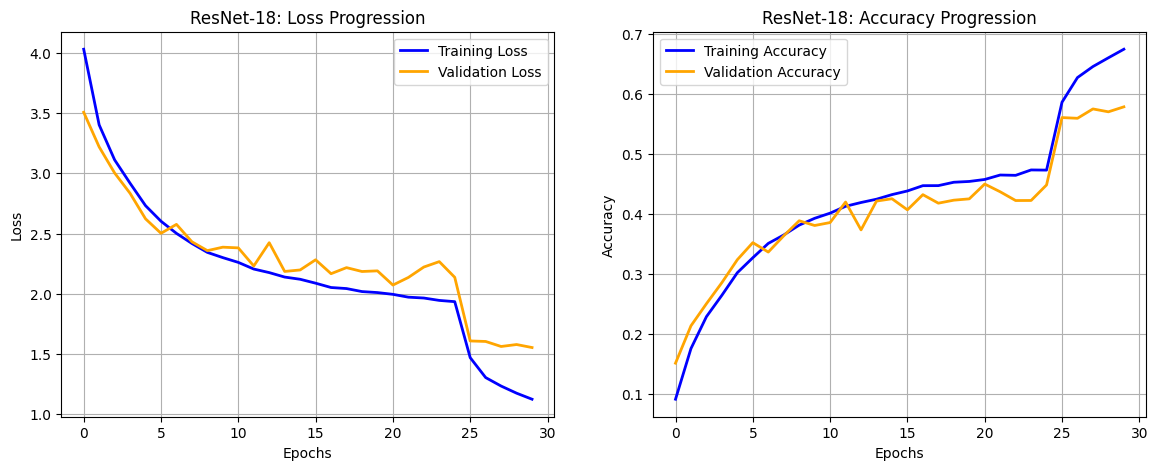


     FINAL CLASSIFICATION REPORT: RESNET-18     
              precision    recall  f1-score   support

           0       0.85      0.73      0.78       100
           1       0.67      0.65      0.66       100
           2       0.34      0.44      0.39       100
           3       0.34      0.31      0.32       100
           4       0.39      0.41      0.40       100
           5       0.63      0.63      0.63       100
           6       0.64      0.70      0.67       100
           7       0.67      0.64      0.66       100
           8       0.67      0.74      0.70       100
           9       0.79      0.69      0.74       100
          10       0.45      0.44      0.45       100
          11       0.45      0.34      0.39       100
          12       0.68      0.63      0.65       100
          13       0.48      0.54      0.51       100
          14       0.54      0.55      0.54       100
          15       0.49      0.47      0.48       100
          16       0.55      0.

In [ ]:
# =====================================================================
# 1. MANUALLY TUNE HYPERPARAMETERS FOR RESNET-18
# =====================================================================
# You can change these numbers anytime to experiment with tuning!
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 0.1
WEIGHT_DECAY = 5e-4

print(f"--- Starting Baseline Experiment: ResNet-18 ---")
print(f"Hyperparameters: Batch Size={BATCH_SIZE}, Epochs={EPOCHS}, LR={LEARNING_RATE}\n")

# =====================================================================
# 2. INITIALIZE DATALOADERS & ARCHITECTURE
# =====================================================================
# Setting up loaders with this cell's custom batch size
current_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
current_test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Load the ResNet-18 structure
model = torchvision.models.resnet18()

# Crucial: Change the final fully connected layer to output 100 classes instead of 1000
model.fc = nn.Linear(model.fc.in_features, 100)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=WEIGHT_DECAY)

# Learning Rate Scheduler: Automatically drops LR by 10x if validation loss stops improving for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

# History trackers for plotting curves later
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# =====================================================================
# 3. MANUALLY CONTROLLED TRAINING LOOP
# =====================================================================
start_time = time.time()

for epoch in range(EPOCHS):
    # --- Training Phase ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in current_train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    # --- Validation Phase ---
    model.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in current_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_dataset)
    epoch_val_acc = val_correct / val_total

    # Update scheduler based on validation loss
    scheduler.step(epoch_val_loss)

    # Save statistics for the metrics dashboard
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] | "
          f"Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc*100:6.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc*100:6.2f}%")

print(f"\nResNet-18 training completed in: {(time.time() - start_time)/60:.2f} minutes.")

# =====================================================================
# 4. EXPERIMENT PRESENTATION & EVALUATION DASHBOARD
# =====================================================================
# Generate Loss and Accuracy Performance Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(val_losses, label='Validation Loss', color='orange', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-18: Loss Progression')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy', color='blue', lw=2)
plt.plot(val_accs, label='Validation Accuracy', color='orange', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet-18: Accuracy Progression')
plt.legend()
plt.grid(True)
plt.show()

# Calculate Final Professional Evaluation Metrics (Precision, Recall, F1)
from sklearn.metrics import classification_report

all_preds, all_labels = [], []
model.eval()

with torch.no_grad():
    for images, labels in current_test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n" + "="*60)
print("     FINAL CLASSIFICATION REPORT: RESNET-18     ")
print("="*60)
print(classification_report(all_labels, all_preds, zero_division=0))

--- Starting Tuned Experiment: ResNet-18 ---
Hyperparameters: Batch Size=128, Epochs=50, LR=0.05

Epoch [01/50] | Train Loss: 4.0063  Acc:   9.41% | Val Loss: 3.5214  Acc:  16.24%
Epoch [02/50] | Train Loss: 3.3892  Acc:  17.69% | Val Loss: 3.2136  Acc:  21.43%
Epoch [03/50] | Train Loss: 3.0703  Acc:  23.45% | Val Loss: 2.9023  Acc:  26.64%
Epoch [04/50] | Train Loss: 2.8121  Acc:  28.40% | Val Loss: 2.6917  Acc:  31.15%
Epoch [05/50] | Train Loss: 2.6217  Acc:  32.27% | Val Loss: 2.7066  Acc:  31.27%
Epoch [06/50] | Train Loss: 2.4822  Acc:  35.49% | Val Loss: 2.6347  Acc:  32.48%
Epoch [07/50] | Train Loss: 2.3629  Acc:  37.71% | Val Loss: 2.4441  Acc:  37.07%
Epoch [08/50] | Train Loss: 2.2642  Acc:  39.89% | Val Loss: 2.3414  Acc:  39.12%
Epoch [09/50] | Train Loss: 2.1726  Acc:  41.83% | Val Loss: 2.2339  Acc:  41.19%
Epoch [10/50] | Train Loss: 2.0917  Acc:  43.58% | Val Loss: 2.1674  Acc:  42.79%
Epoch [11/50] | Train Loss: 2.0255  Acc:  45.28% | Val Loss: 2.1552  Acc:  43.74%


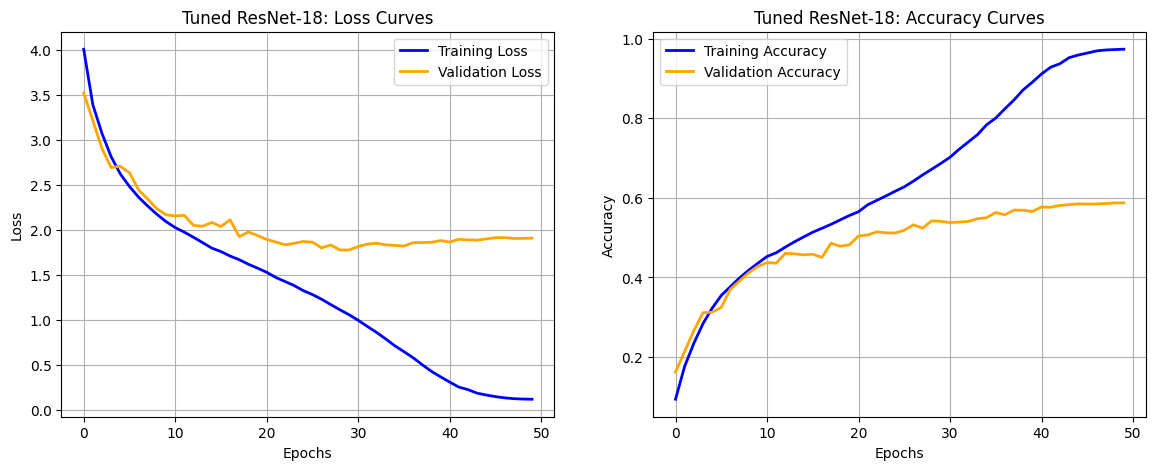


     FINAL CLASSIFICATION REPORT: TUNED RESNET-18     
              precision    recall  f1-score   support

           0       0.80      0.79      0.79       100
           1       0.64      0.71      0.67       100
           2       0.41      0.40      0.40       100
           3       0.39      0.40      0.39       100
           4       0.44      0.52      0.48       100
           5       0.60      0.68      0.64       100
           6       0.67      0.64      0.65       100
           7       0.51      0.60      0.55       100
           8       0.75      0.65      0.70       100
           9       0.74      0.70      0.72       100
          10       0.36      0.29      0.32       100
          11       0.41      0.41      0.41       100
          12       0.60      0.67      0.64       100
          13       0.55      0.53      0.54       100
          14       0.51      0.46      0.48       100
          15       0.53      0.58      0.55       100
          16       0.61  

In [ ]:
# =====================================================================
# 1. TUNED HYPERPARAMETERS FOR RESNET-18
# =====================================================================
BATCH_SIZE = 128
EPOCHS = 50                # Increased to allow smooth cosine decay convergence
LEARNING_RATE = 0.05       # Lowered starting rate to avoid erratic early bouncing
WEIGHT_DECAY = 5e-4

print(f"--- Starting Tuned Experiment: ResNet-18 ---")
print(f"Hyperparameters: Batch Size={BATCH_SIZE}, Epochs={EPOCHS}, LR={LEARNING_RATE}\n")

# =====================================================================
# 2. INITIALIZE DATALOADERS & ARCHITECTURE
# =====================================================================
current_train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
current_test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

model_tuned = torchvision.models.resnet18()
model_tuned.fc = nn.Linear(model_tuned.fc.in_features, 100)
model_tuned = model_tuned.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_tuned.parameters(), lr=LEARNING_RATE, momentum=0.9, weight_decay=WEIGHT_DECAY)

# NEW SCHEDULER: Smoothly decays the learning rate to near 0 using a cosine wave
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

tuned_train_losses, tuned_val_losses = [], []
tuned_train_accs, tuned_val_accs = [], []

# =====================================================================
# 3. TRAINING LOOP
# =====================================================================
start_time = time.time()

for epoch in range(EPOCHS):
    model_tuned.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in current_train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_tuned(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    # Validation Phase
    model_tuned.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in current_test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_tuned(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_dataset)
    epoch_val_acc = val_correct / val_total

    # step the scheduler at the end of every single epoch
    scheduler.step()

    tuned_train_losses.append(epoch_train_loss)
    tuned_val_losses.append(epoch_val_loss)
    tuned_train_accs.append(epoch_train_acc)
    tuned_val_accs.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS:02d}] | "
          f"Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc*100:6.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc*100:6.2f}%")

print(f"\nTuned ResNet-18 training completed in: {(time.time() - start_time)/60:.2f} minutes.")

# =====================================================================
# 4. EVALUATION DASHBOARD
# =====================================================================
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(tuned_train_losses, label='Training Loss', color='blue', lw=2)
plt.plot(tuned_val_losses, label='Validation Loss', color='orange', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Tuned ResNet-18: Loss Curves')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(tuned_train_accs, label='Training Accuracy', color='blue', lw=2)
plt.plot(tuned_val_accs, label='Validation Accuracy', color='orange', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Tuned ResNet-18: Accuracy Curves')
plt.legend()
plt.grid(True)
plt.show()

from sklearn.metrics import classification_report
all_preds, all_labels = [], []
model_tuned.eval()
with torch.no_grad():
    for images, labels in current_test_loader:
        images = images.to(device)
        outputs = model_tuned(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print("\n" + "="*60)
print("     FINAL CLASSIFICATION REPORT: TUNED RESNET-18     ")
print("="*60)
print(classification_report(all_labels, all_preds, zero_division=0))

In [ ]:
# =====================================================================
# RESNET-18 (MAX 100 EPOCHS + EARLY STOPPING)
# =====================================================================
import time

BATCH_SIZE = 128
EPOCHS = 100               # High ceiling to allow complete convergence
LEARNING_RATE = 0.001      # Precise learning rate for smooth tuning
WEIGHT_DECAY = 1e-4
PATIENCE = 10              # Halts if validation loss stalls for 10 epochs

# Reset early stopping trackers
best_val_loss = float('inf')
patience_counter = 0

print(f"--- 🚀 Running ResNet-18 (Max 100 Epochs + Early Stopping) ---")

# =====================================================================
# 1. ARCHITECTURE SETUP FOR CIFAR-100 SMALL IMAGES
# =====================================================================
model_r18 = torchvision.models.resnet18()

# Modify first layers to prevent detail destruction on 32x32 images
model_r18.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_r18.maxpool = nn.Identity()

# Modify the final classification head for 100 target classes
num_ftrs = model_r18.fc.in_features
model_r18.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_ftrs, 100)
)
model_r18 = model_r18.to(device)

# Optimization tools matching advanced benchmarks
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_r18.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Trackers for history mapping
r18_losses, r18_val_losses = [], []
r18_accs, r18_val_accs = [], []

# =====================================================================
# 2. UNIFIED TRAINING ENGINE LOOP
# =====================================================================
start_time = time.time()

for epoch in range(EPOCHS):
    model_r18.train()
    running_loss, correct, total = 0.0, 0, 0

    # Using your globally defined 'train_loader'
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_r18(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    # Validation Evaluation Phase
    model_r18.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        # Using your globally defined 'test_loader'
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_r18(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_dataset)
    epoch_val_acc = val_correct / val_total

    scheduler.step()

    r18_losses.append(epoch_train_loss)
    r18_val_losses.append(epoch_val_loss)
    r18_accs.append(epoch_train_acc)
    r18_val_accs.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

    # =====================================================================
    # 3. DYNAMIC EARLY STOPPING EVALUATION
    # =====================================================================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model_r18.state_dict(), 'best_r18_100epochs.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"🛑 Early stopping triggered! Stagnant for {PATIENCE} epochs. Halted to prevent overfitting.")
            break

# Restore the absolute best parameters found during the run
model_r18.load_state_dict(torch.load('best_r18_100epochs.pth'))
print(f"Done! Best optimization weights restored. Total Runtime: {(time.time() - start_time)/60:.2f} mins.")

--- 🚀 Running ResNet-18 (Max 100 Epochs + Early Stopping) ---
Epoch [001/100] | Train Loss: 3.8930 Acc: 13.02% | Val Loss: 3.6434 Acc: 18.59%
Epoch [002/100] | Train Loss: 3.2556 Acc: 25.92% | Val Loss: 3.1248 Acc: 30.20%
Epoch [003/100] | Train Loss: 2.8719 Acc: 36.07% | Val Loss: 2.8095 Acc: 37.83%
Epoch [004/100] | Train Loss: 2.6098 Acc: 43.32% | Val Loss: 2.6136 Acc: 43.83%
Epoch [005/100] | Train Loss: 2.4132 Acc: 48.96% | Val Loss: 2.4741 Acc: 47.53%
Epoch [006/100] | Train Loss: 2.2642 Acc: 53.27% | Val Loss: 2.4029 Acc: 49.62%
Epoch [007/100] | Train Loss: 2.1392 Acc: 57.09% | Val Loss: 2.2469 Acc: 53.76%
Epoch [008/100] | Train Loss: 2.0270 Acc: 60.76% | Val Loss: 2.3120 Acc: 52.58%
Epoch [009/100] | Train Loss: 1.9361 Acc: 63.37% | Val Loss: 2.0664 Acc: 59.69%
Epoch [010/100] | Train Loss: 1.8512 Acc: 66.27% | Val Loss: 2.1221 Acc: 58.09%
Epoch [011/100] | Train Loss: 1.7758 Acc: 68.83% | Val Loss: 2.0402 Acc: 60.49%
Epoch [012/100] | Train Loss: 1.7046 Acc: 71.05% | Val Los

Target Execution Device: cuda
--- 🚀 Starting Step 4: ResNet-34 Pipeline ---
Epoch [001/100] | Train Loss: 4.1315 Acc: 8.07% | Val Loss: 3.8942 Acc: 14.39%
Epoch [002/100] | Train Loss: 3.5726 Acc: 18.55% | Val Loss: 3.3020 Acc: 24.73%
Epoch [003/100] | Train Loss: 3.1421 Acc: 28.67% | Val Loss: 2.9183 Acc: 34.82%
Epoch [004/100] | Train Loss: 2.8209 Acc: 37.10% | Val Loss: 2.6571 Acc: 41.76%
Epoch [005/100] | Train Loss: 2.5801 Acc: 43.55% | Val Loss: 2.4930 Acc: 46.09%
Epoch [006/100] | Train Loss: 2.3946 Acc: 49.04% | Val Loss: 2.3978 Acc: 48.99%
Epoch [007/100] | Train Loss: 2.2459 Acc: 53.22% | Val Loss: 2.2499 Acc: 52.93%
Epoch [008/100] | Train Loss: 2.1282 Acc: 56.84% | Val Loss: 2.1825 Acc: 55.50%
Epoch [009/100] | Train Loss: 2.0229 Acc: 60.11% | Val Loss: 2.1808 Acc: 55.72%
Epoch [010/100] | Train Loss: 1.9334 Acc: 63.10% | Val Loss: 2.0274 Acc: 59.80%
Epoch [011/100] | Train Loss: 1.8462 Acc: 65.59% | Val Loss: 2.0405 Acc: 60.52%
Epoch [012/100] | Train Loss: 1.7687 Acc: 68.

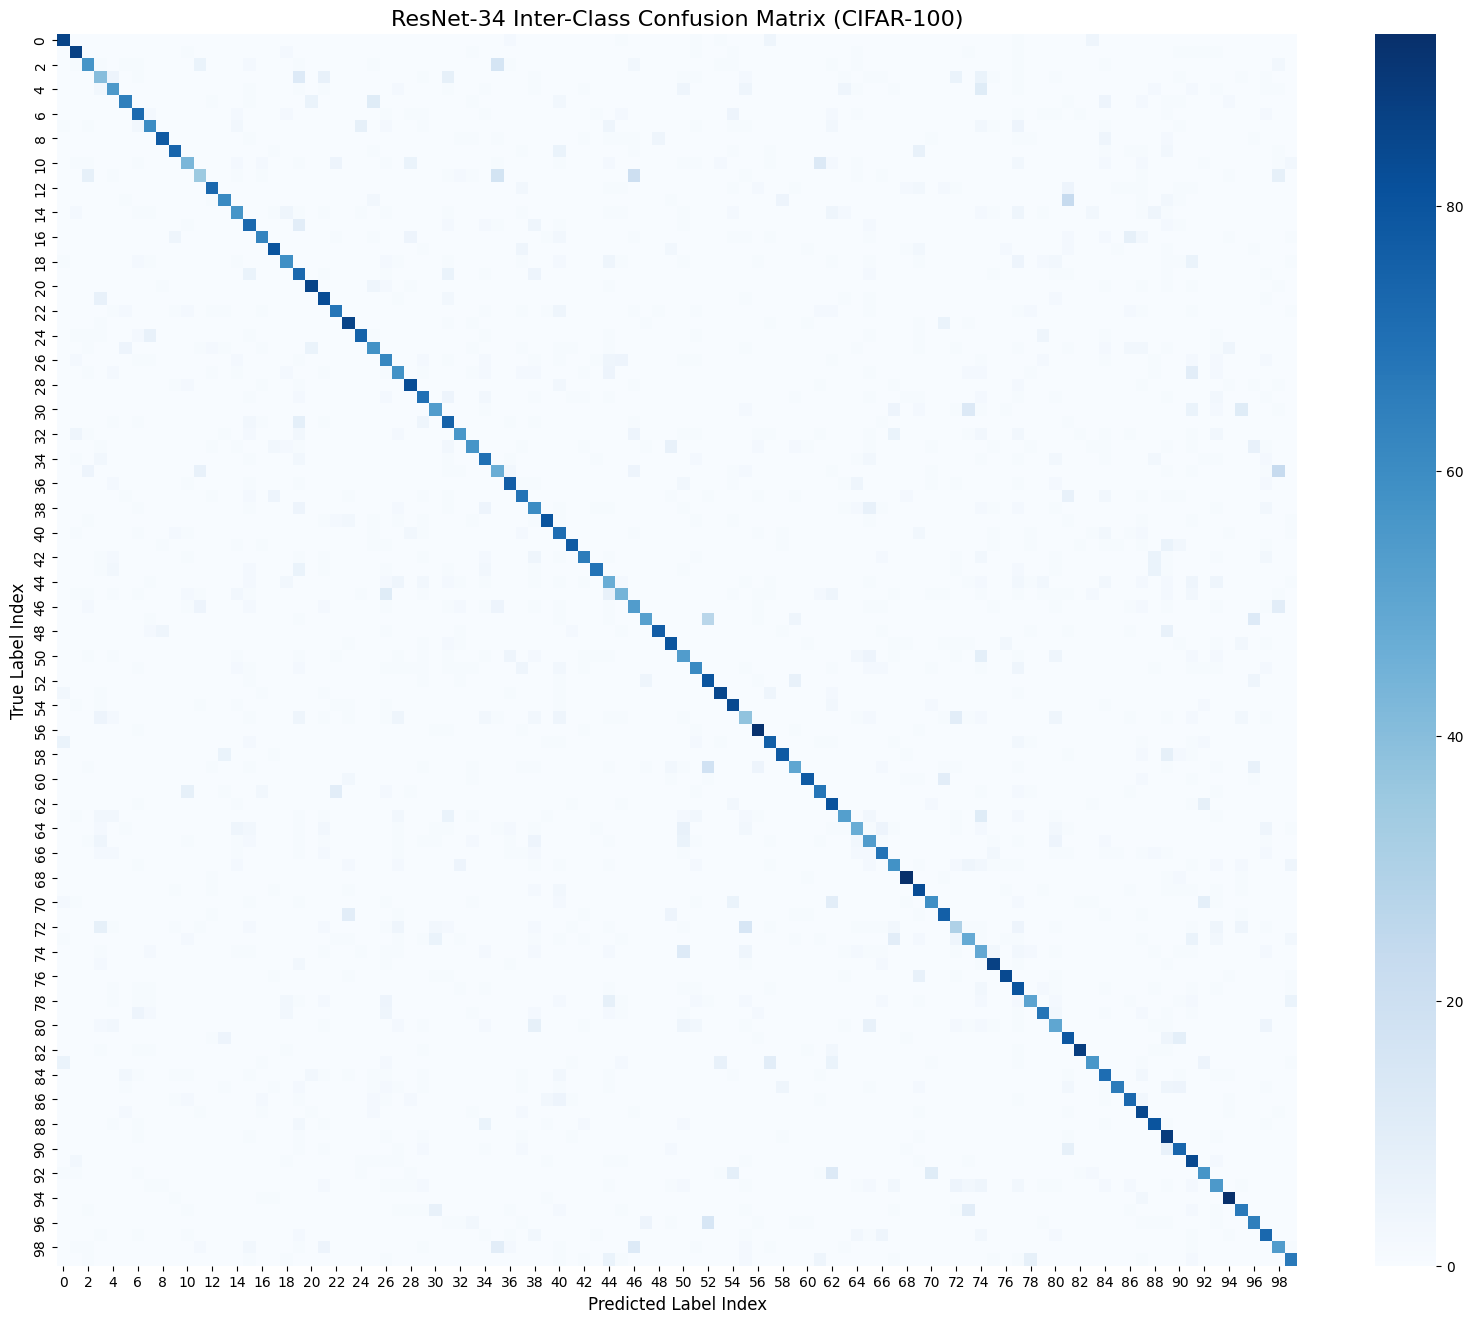

In [ ]:
# =====================================================================
# STEP 4: RESNET-34 TRAINING ENGINE + COMPLETION METRICS PIPELINE
# =====================================================================
import time
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. RUNTIME RECOVERY & DATA BOOTSTRAP ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Target Execution Device: {device}")

# Re-establishing standard data transforms
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

# Loading datasets locally (pointing to your patched './data' directory)
data_dir = "./data"
train_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=False, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=False, transform=transform_test)

# --- 2. CONFIGURATION & LOADERS ---
BATCH_SIZE = 128
EPOCHS = 100
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
PATIENCE = 10

best_val_loss = float('inf')
patience_counter = 0

print(f"--- 🚀 Starting Step 4: ResNet-34 Pipeline ---")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 3. ARCHITECTURE BUILD ---
model_r34 = torchvision.models.resnet34()

# Custom topology adjustments for 32x32 image sizes
model_r34.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_r34.maxpool = nn.Identity()

num_ftrs = model_r34.fc.in_features
model_r34.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_ftrs, 100)
)
model_r34 = model_r34.to(device)

# --- 4. OPTIMIZATION SETTING ---
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_r34.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

r34_losses, r34_val_losses = [], []
r34_accs, r34_val_accs = [], []

# --- 5. EXECUTION TRAINING LOOP ---
start_time = time.time()
for epoch in range(EPOCHS):
    model_r34.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_r34(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    # Validation Phase
    model_r34.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_r34(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_dataset)
    epoch_val_acc = val_correct / val_total
    scheduler.step()

    r34_losses.append(epoch_train_loss)
    r34_val_losses.append(epoch_val_loss)
    r34_accs.append(epoch_train_acc)
    r34_val_accs.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

    # Early Stopping Logic
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model_r34.state_dict(), 'best_r34_step4.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"🛑 Early stopping triggered at epoch {epoch+1}! Halted to prevent overfitting.")
            break

# Restore best checkpoint parameters
model_r34.load_state_dict(torch.load('best_r34_step4.pth'))
print(f"Done! Step 4 training complete in: {(time.time() - start_time)/60:.2f} mins.\n")

# --- 6. EVALUATION METRICS SUITE ---
print("============================================================")
print("     FINAL CLASSIFICATION REPORT: RESNET-34     ")
print("============================================================")

model_r34.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_r34(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate Precision, Recall, F1-Score Metrics
print(classification_report(all_labels, all_preds, digits=4))

# Generate and Display Confusion Matrix Visualization
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title('ResNet-34 Inter-Class Confusion Matrix (CIFAR-100)', fontsize=16)
plt.xlabel('Predicted Label Index', fontsize=12)
plt.ylabel('True Label Index', fontsize=12)
plt.show()

--- Generating Diagnostic Performance Curves for ResNet-34 ---


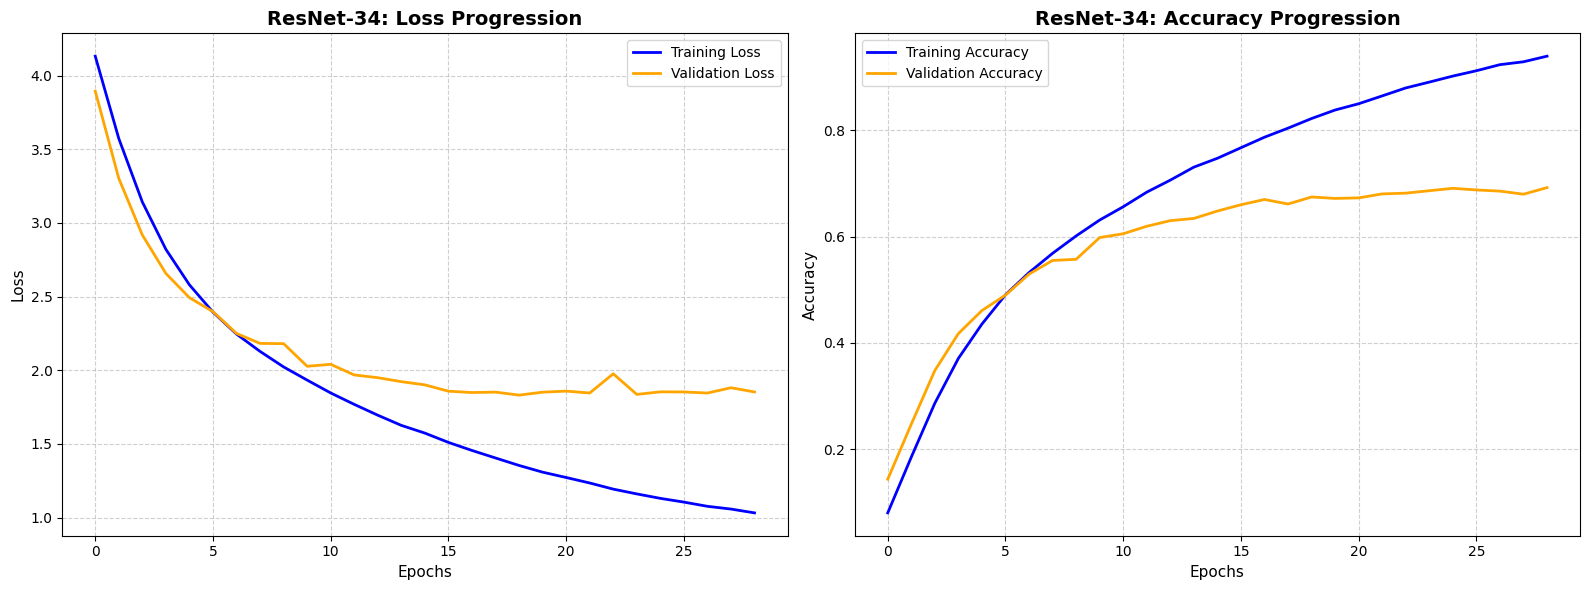

In [ ]:
# =====================================================================
# STEP 4 DIAGNOSTICS: RESNET-34 LOSS/ACCURACY CURVES
# =====================================================================
import matplotlib.pyplot as plt

print("--- Generating Diagnostic Performance Curves for ResNet-34 ---")

# Setup the side-by-side plot layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Plot Loss Curves
ax1.plot(r34_losses, label='Training Loss', color='blue', linewidth=2)
ax1.plot(r34_val_losses, label='Validation Loss', color='orange', linewidth=2)
ax1.set_title('ResNet-34: Loss Progression', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(fontsize=10)

# 2. Plot Accuracy Curves
ax2.plot(r34_accs, label='Training Accuracy', color='blue', linewidth=2)
ax2.plot(r34_val_accs, label='Validation Accuracy', color='orange', linewidth=2)
ax2.set_title('ResNet-34: Accuracy Progression', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Accuracy', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

Target Execution Device: cuda
--- 🚀 Starting Step 5: ResNet-50 (Bottleneck Design Scaling) ---
Epoch [001/100] | Train Loss: 4.1464 Acc: 8.57% | Val Loss: 3.8165 Acc: 14.86%
Epoch [002/100] | Train Loss: 3.5153 Acc: 19.93% | Val Loss: 3.3978 Acc: 24.94%
Epoch [003/100] | Train Loss: 3.0397 Acc: 31.48% | Val Loss: 3.0330 Acc: 35.66%
Epoch [004/100] | Train Loss: 2.7229 Acc: 40.01% | Val Loss: 2.5875 Acc: 45.22%
Epoch [005/100] | Train Loss: 2.4852 Acc: 46.79% | Val Loss: 2.5133 Acc: 46.31%
Epoch [006/100] | Train Loss: 2.3377 Acc: 51.30% | Val Loss: 2.4375 Acc: 50.29%
Epoch [007/100] | Train Loss: 2.1798 Acc: 55.73% | Val Loss: 2.2423 Acc: 55.62%
Epoch [008/100] | Train Loss: 2.0868 Acc: 58.59% | Val Loss: 2.1479 Acc: 57.16%
Epoch [009/100] | Train Loss: 1.9740 Acc: 62.25% | Val Loss: 2.0715 Acc: 60.49%
Epoch [010/100] | Train Loss: 1.8931 Acc: 64.67% | Val Loss: 2.0287 Acc: 60.50%
Epoch [011/100] | Train Loss: 1.8425 Acc: 66.02% | Val Loss: 2.0036 Acc: 61.52%
Epoch [012/100] | Train Lo

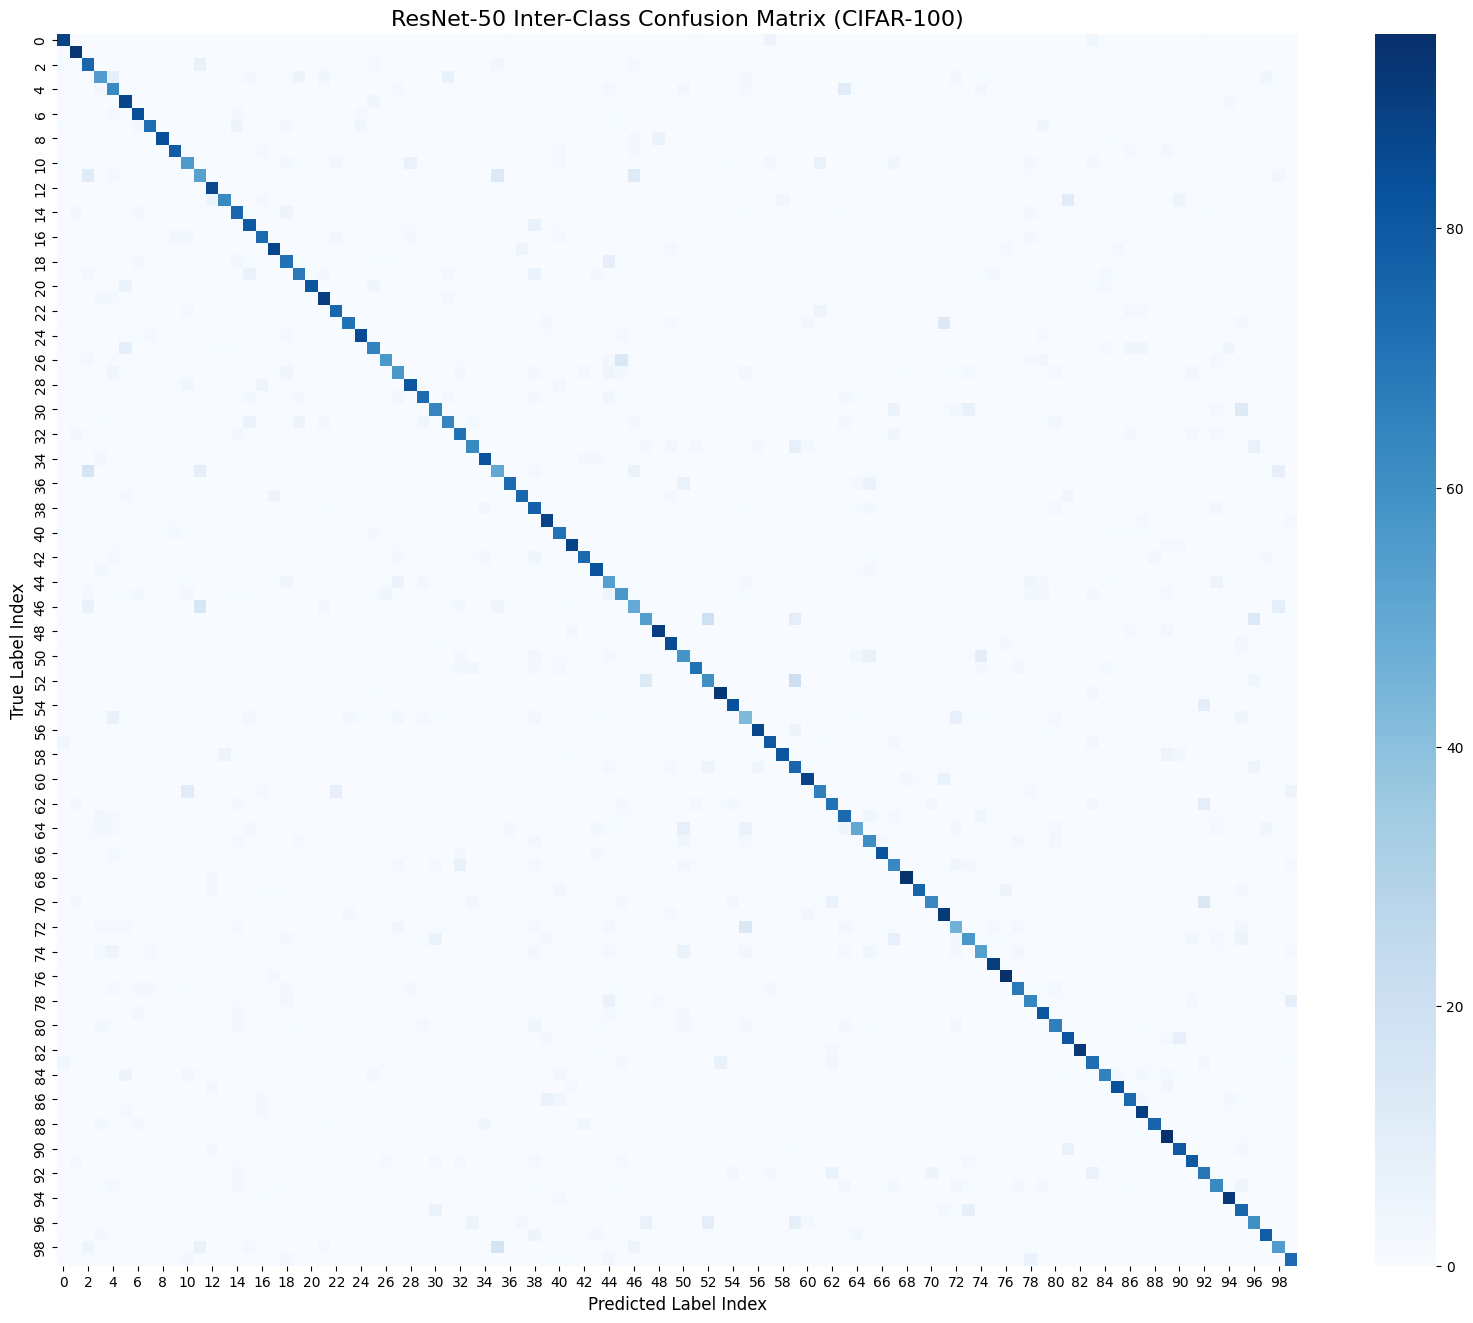

In [ ]:
# =====================================================================
# STEP 5: SCALE ARCHITECTURAL CAPACITY TO RESNET-50
# =====================================================================
import time
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. RUNTIME RECOVERY & DATA BOOTSTRAP ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Target Execution Device: {device}")

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761))
])

data_dir = "./data"
train_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=False, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=False, transform=transform_test)

# --- 2. CONFIGURATION & LOADERS (Optimized for ResNet-50 VRAM demands) ---
BATCH_SIZE = 64             # Lowered to 64 to protect GPU memory
EPOCHS = 100
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
PATIENCE = 10

best_val_loss = float('inf')
patience_counter = 0

print(f"--- 🚀 Starting Step 5: ResNet-50 (Bottleneck Design Scaling) ---")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 3. ARCHITECTURE BUILD ---
model_r50 = torchvision.models.resnet50()

# Custom topology adjustments for 32x32 image sizes
model_r50.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_r50.maxpool = nn.Identity()

num_ftrs = model_r50.fc.in_features
model_r50.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_ftrs, 100)
)
model_r50 = model_r50.to(device)

# --- 4. OPTIMIZATION SETTING ---
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_r50.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

r50_losses, r50_val_losses = [], []
r50_accs, r50_val_accs = [], []

# --- 5. EXECUTION TRAINING LOOP ---
start_time = time.time()
for epoch in range(EPOCHS):
    model_r50.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_r50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    # Validation Phase
    model_r50.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_r50(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_dataset)
    epoch_val_acc = val_correct / val_total
    scheduler.step()

    r50_losses.append(epoch_train_loss)
    r50_val_losses.append(epoch_val_loss)
    r50_accs.append(epoch_train_acc)
    r50_val_accs.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

    # Early Stopping Logic
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model_r50.state_dict(), 'best_r50_step5.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"🛑 Early stopping triggered at epoch {epoch+1}! Halted to prevent overfitting.")
            break

# Restore best checkpoint parameters
model_r50.load_state_dict(torch.load('best_r50_step5.pth'))
print(f"Done! Step 5 training complete in: {(time.time() - start_time)/60:.2f} mins.\n")

# --- 6. EVALUATION METRICS SUITE ---
print("============================================================")
print("     FINAL CLASSIFICATION REPORT: RESNET-50     ")
print("============================================================")

model_r50.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_r50(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title('ResNet-50 Inter-Class Confusion Matrix (CIFAR-100)', fontsize=16)
plt.xlabel('Predicted Label Index', fontsize=12)
plt.ylabel('True Label Index', fontsize=12)
plt.show()

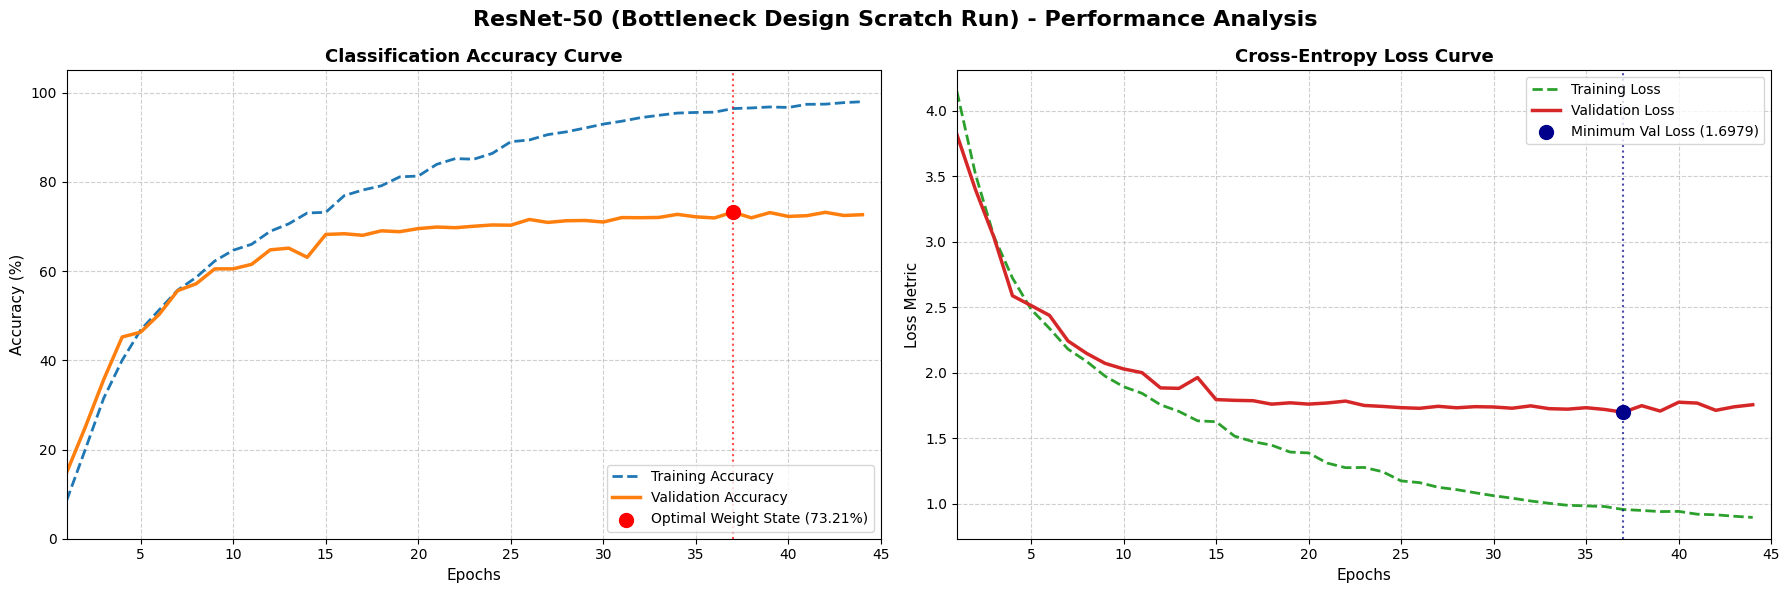

In [ ]:
# =====================================================================
# STEP 5.5: RESNET-50 (BOTTLENECK) TRAINING CURVES VISUALIZATION
# =====================================================================
import matplotlib.pyplot as plt

# --- 1. FILL DATA FROM YOUR LIVE RUN LOGS ---
# We populate the exact number of epochs your model completed (44 epochs)
epochs = list(range(1, 45))

# Training and Validation Accuracies (%) converted from your terminal dump
train_acc = [
    8.57, 19.93, 31.48, 40.01, 46.79, 51.30, 55.73, 58.59, 62.25, 64.67,
    66.02, 68.92, 70.59, 73.02, 73.17, 76.91, 78.17, 79.11, 81.12, 81.30,
    83.93, 85.21, 85.08, 86.38, 89.00, 89.39, 90.59, 91.21, 92.06, 92.95,
    93.60, 94.38, 94.92, 95.42, 95.56, 95.62, 96.43, 96.57, 96.79, 96.68,
    97.38, 97.42, 97.76, 97.97
]

val_acc = [
    14.86, 24.94, 35.66, 45.22, 46.31, 50.29, 55.62, 57.16, 60.49, 60.50,
    61.52, 64.76, 65.14, 63.09, 68.21, 68.37, 68.02, 69.02, 68.83, 69.52,
    69.87, 69.72, 70.05, 70.34, 70.28, 71.57, 70.91, 71.28, 71.34, 71.00,
    71.99, 71.96, 72.02, 72.71, 72.16, 71.91, 73.21, 71.94, 73.11, 72.25,
    72.42, 73.17, 72.46, 72.64
]

# Training and Validation Losses from your terminal dump
train_loss = [
    4.1464, 3.5153, 3.0397, 2.7229, 2.4852, 2.3377, 2.1798, 2.0868, 1.9740, 1.8931,
    1.8425, 1.7546, 1.7040, 1.6325, 1.6256, 1.5153, 1.4734, 1.4465, 1.3939, 1.3872,
    1.3100, 1.2745, 1.2764, 1.2438, 1.1735, 1.1603, 1.1248, 1.1069, 1.0829, 1.0604,
    1.0417, 1.0202, 1.0024, 0.9873, 0.9828, 0.9778, 0.9553, 0.9480, 0.9393, 0.9408,
    0.9193, 0.9149, 0.9036, 0.8946
]

val_loss = [
    3.8165, 3.3978, 3.0330, 2.5875, 2.5133, 2.4375, 2.2423, 2.1479, 2.0715, 2.0287,
    2.0003, 1.8838, 1.8803, 1.9629, 1.7946, 1.7888, 1.7860, 1.7596, 1.7700, 1.7600,
    1.7685, 1.7830, 1.7498, 1.7424, 1.7328, 1.7280, 1.7432, 1.7319, 1.7405, 1.7380,
    1.7285, 1.7467, 1.7251, 1.7214, 1.7326, 1.7191, 1.6979, 1.7479, 1.7069, 1.7745,
    1.7678, 1.7125, 1.7395, 1.7554
]

# --- 2. CANVAS SETUP ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('ResNet-50 (Bottleneck Design Scratch Run) - Performance Analysis', fontsize=16, fontweight='bold')

# --- 3. GRAPH 1: ACCURACY CURVES ---
ax1.plot(epochs, train_acc, label='Training Accuracy', color='#1f77b4', linewidth=2, linestyle='--')
ax1.plot(epochs, val_acc, label='Validation Accuracy', color='#ff7f0e', linewidth=2.5)
# Mark the peak performance location
ax1.scatter(37, 73.21, color='red', s=100, zorder=5, label='Optimal Weight State (73.21%)')
ax1.axvline(37, color='red', linestyle=':', alpha=0.7)

ax1.set_title('Classification Accuracy Curve', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_xlim(1, 45)
ax1.set_ylim(0, 105)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='lower right', fontsize=10)

# --- 4. GRAPH 2: CROSS-ENTROPY LOSS CURVES ---
ax2.plot(epochs, train_loss, label='Training Loss', color='#2ca02c', linewidth=2, linestyle='--')
ax2.plot(epochs, val_loss, label='Validation Loss', color='#d62728', linewidth=2.5)
# Mark the early stopping minimum loss location
ax2.scatter(37, 1.6979, color='darkblue', s=100, zorder=5, label='Minimum Val Loss (1.6979)')
ax2.axvline(37, color='darkblue', linestyle=':', alpha=0.7)

ax2.set_title('Cross-Entropy Loss Curve', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Loss Metric', fontsize=11)
ax2.set_xlim(1, 45)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right', fontsize=10)

# --- 5. RENDER GRAPHICS ---
plt.tight_layout()
plt.show()

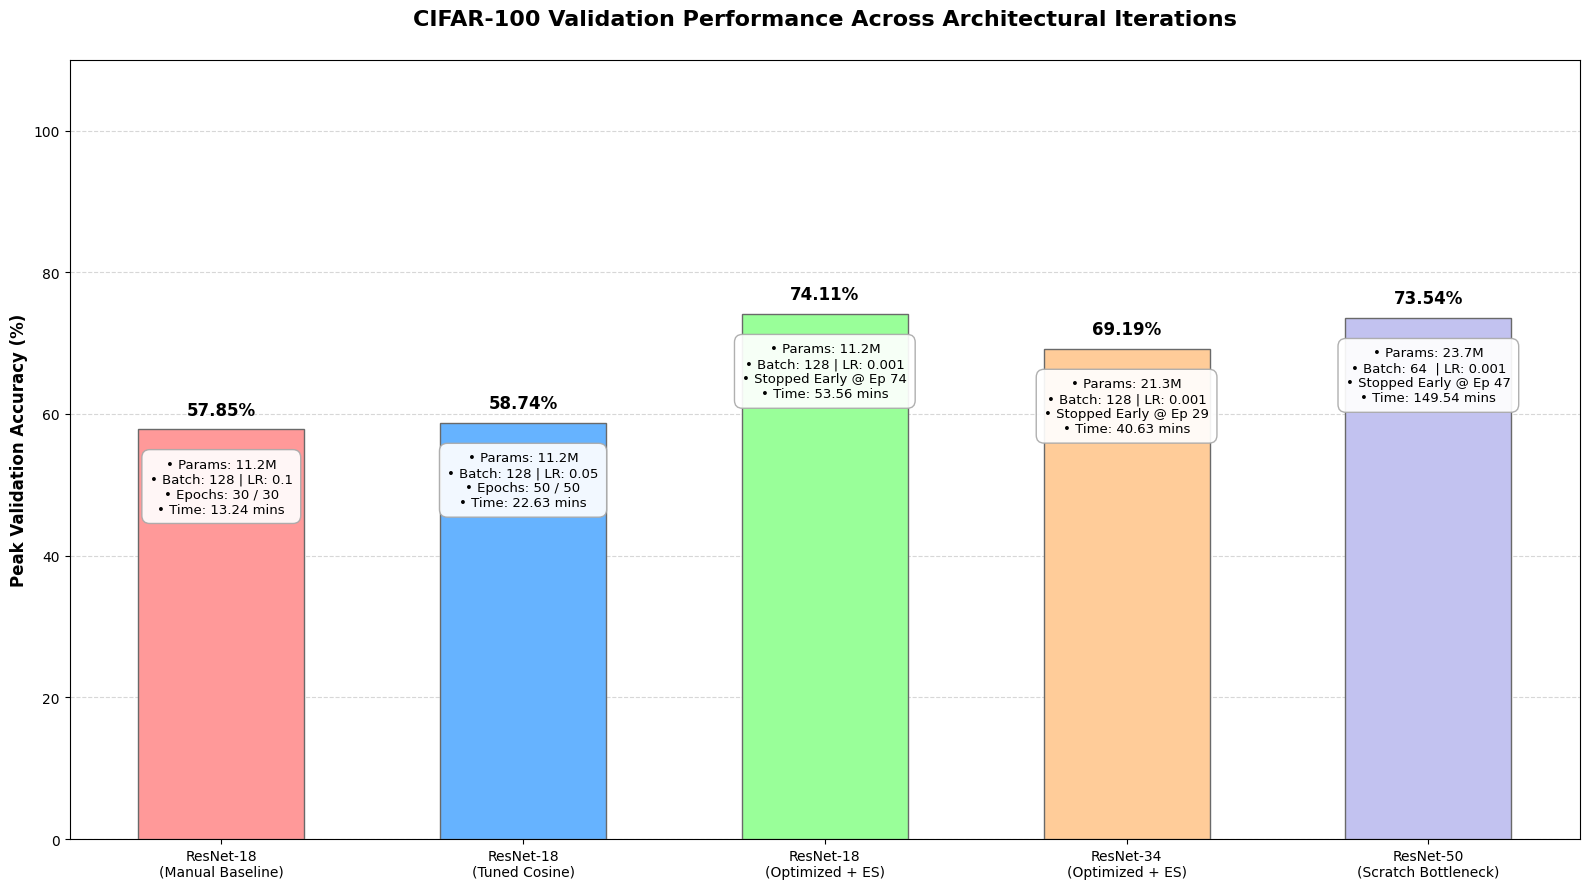

In [ ]:
# =====================================================================
# RAW VERIFIED METRICS COMPARATIVE PLOT (CIFAR-100)
# =====================================================================
import matplotlib.pyplot as plt

# --- 1. DATASET PREPARATION FROM LIVE LOGS ---
models = [
    'ResNet-18\n(Manual Baseline)',
    'ResNet-18\n(Tuned Cosine)',
    'ResNet-18\n(Optimized + ES)',
    'ResNet-34\n(Optimized + ES)',
    'ResNet-50\n(Scratch Bottleneck)'
]

# Exact peak validation accuracies achieved across your five steps
accuracies = [57.85, 58.74, 74.11, 69.19, 73.54]

# Exact metadata descriptors from the raw logs provided
parameter_labels = [
    "• Params: 11.2M\n• Batch: 128 | LR: 0.1\n• Epochs: 30 / 30\n• Time: 13.24 mins",
    "• Params: 11.2M\n• Batch: 128 | LR: 0.05\n• Epochs: 50 / 50\n• Time: 22.63 mins",
    "• Params: 11.2M\n• Batch: 128 | LR: 0.001\n• Stopped Early @ Ep 74\n• Time: 53.56 mins",
    "• Params: 21.3M\n• Batch: 128 | LR: 0.001\n• Stopped Early @ Ep 29\n• Time: 40.63 mins",
    "• Params: 23.7M\n• Batch: 64  | LR: 0.001\n• Stopped Early @ Ep 47\n• Time: 149.54 mins"
]

# --- 2. CONFIGURATION & CANVAS SETUP ---
plt.figure(figsize=(16, 9))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

# Create the bars
bars = plt.bar(models, accuracies, color=colors, edgecolor='dimgray', width=0.55, zorder=3)

# --- 3. STYLING & ACCURACY ANNOTATIONS ---
plt.title('CIFAR-100 Validation Performance Across Architectural Iterations', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Peak Validation Accuracy (%)', fontsize=12, fontweight='bold')
plt.ylim(0, 110) # 110% to prevent the top numbers from hitting the top edge
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Apply dynamic text labeling
for bar, acc, text in zip(bars, accuracies, parameter_labels):
    yval = bar.get_height()

    # Value labels above bars
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

    # Detailed parameter specification box centered inside each bar
    plt.text(bar.get_x() + bar.get_width()/2.0, yval - 4.0, text,
             ha='center', va='top', fontsize=9.5, color='black', fontweight='medium',
             bbox=dict(boxstyle="round,pad=0.6", facecolor='white', edgecolor='darkgray', alpha=0.92))

plt.tight_layout()
plt.show()

Target Execution Device: cuda
--- 🚀 Starting Step 6: ResNet-50 (Pretrained Transfer Learning) ---
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


Epoch [001/50] | Train Loss: 2.7187 Acc: 41.92% | Val Loss: 2.0126 Acc: 60.18%
Epoch [002/50] | Train Loss: 1.8356 Acc: 65.81% | Val Loss: 1.7287 Acc: 69.26%
Epoch [003/50] | Train Loss: 1.6168 Acc: 73.03% | Val Loss: 1.6466 Acc: 71.43%
Epoch [004/50] | Train Loss: 1.4875 Acc: 77.06% | Val Loss: 1.6061 Acc: 72.93%
Epoch [005/50] | Train Loss: 1.3904 Acc: 80.48% | Val Loss: 1.5461 Acc: 75.03%
Epoch [006/50] | Train Loss: 1.3172 Acc: 82.99% | Val Loss: 1.5366 Acc: 75.08%
Epoch [007/50] | Train Loss: 1.2575 Acc: 85.04% | Val Loss: 1.5062 Acc: 76.69%
Epoch [008/50] | Train Loss: 1.2008 Acc: 87.07% | Val Loss: 1.4983 Acc: 76.82%
Epoch [009/50] | Train Loss: 1.1556 Acc: 88.43% | Val Loss: 1.5049 Acc: 76.37%
Epoch [010/50] | Train Loss: 1.1242 Acc: 89.52% | Val Loss: 1.4963 Acc: 77.15%
Epoch [011/50] | Train Loss: 1.0877 Acc: 90.77% | Val Loss: 1.4818 Acc: 77.43%
Epoch [012/50] | Train Loss: 1.0549 Acc: 91.88% | Val Loss: 1.4740 Acc: 78.32%
Epoch [013/50] | Train Loss: 1.0280 Acc: 92.90% | Va

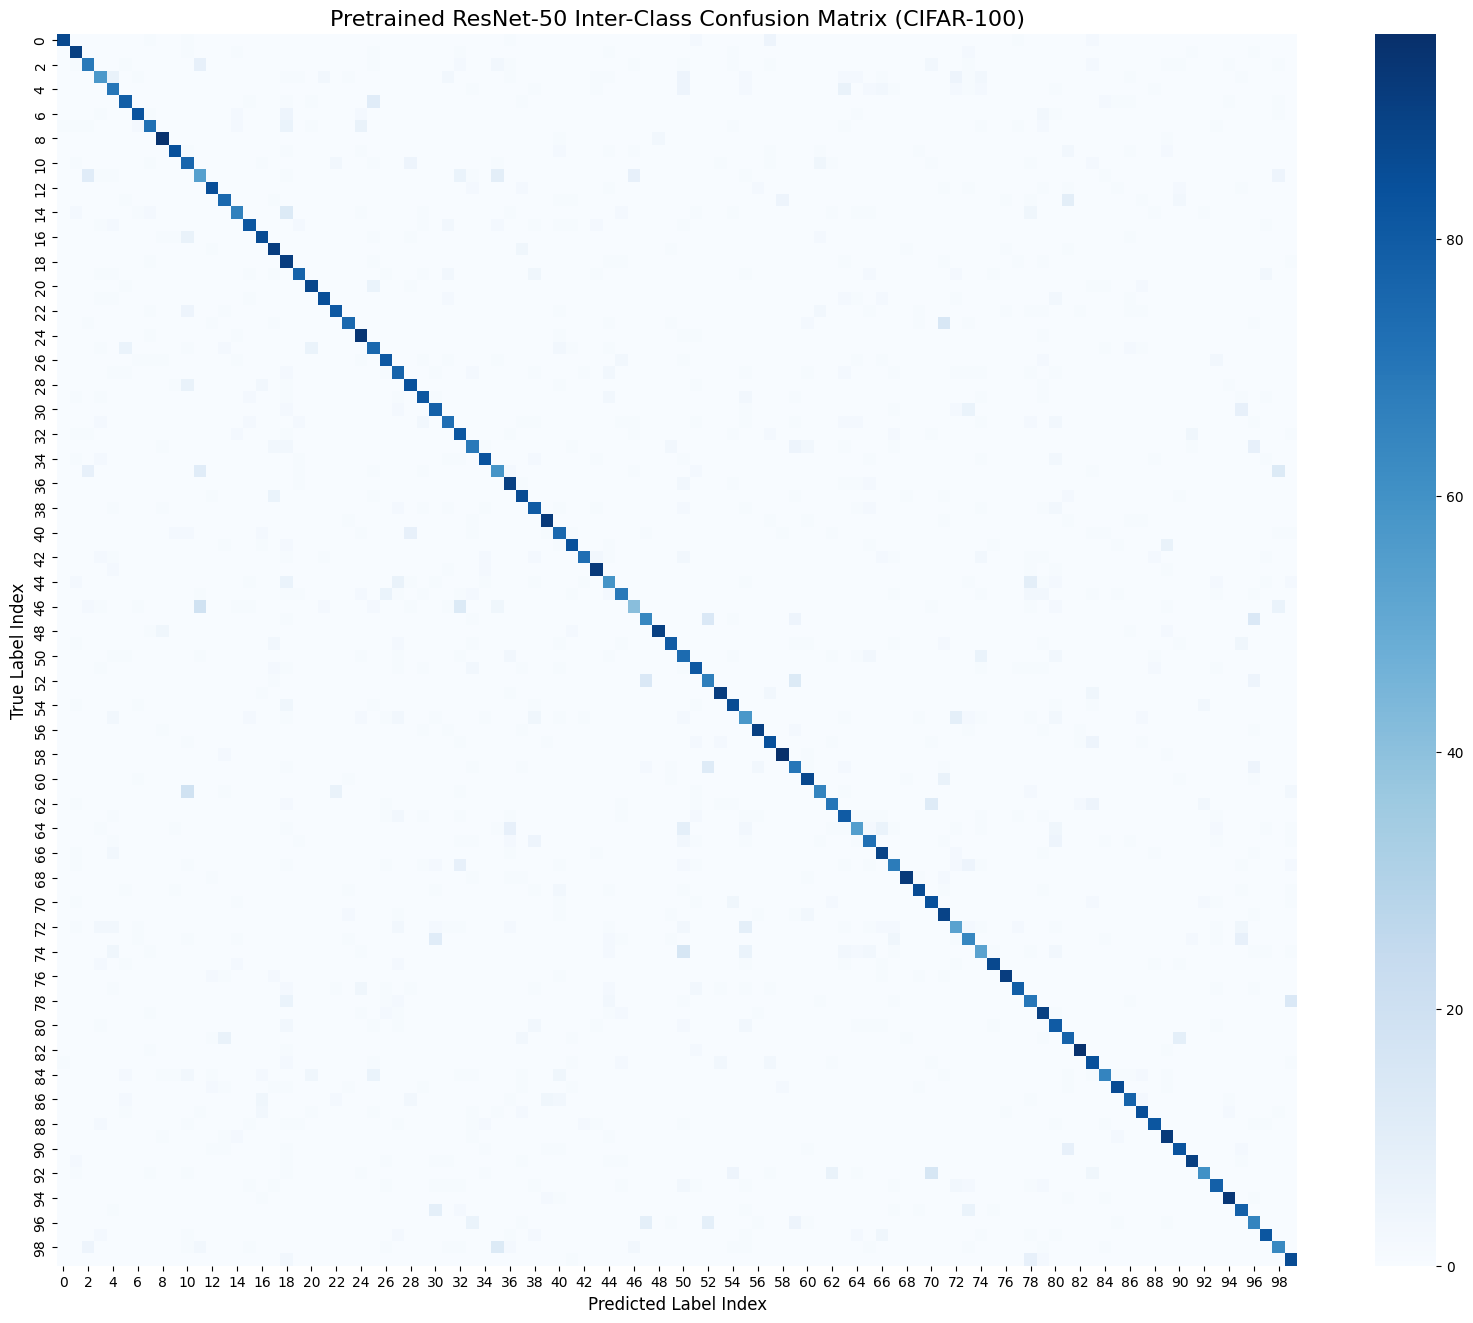

In [ ]:
# =====================================================================
# STEP 6: RESNET-50 WITH TRANSFER LEARNING (IMAGENET PRETRAINED)
# =====================================================================
import time
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. RUNTIME RECOVERY & DATA BOOTSTRAP ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Target Execution Device: {device}")

# Pretrained models expect larger images or standard ImageNet normalizations
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) # ImageNet statistics
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

data_dir = "./data"
train_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=False, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=False, transform=transform_test)

# --- 2. CONFIGURATION & LOADERS ---
BATCH_SIZE = 64
EPOCHS = 50                 # Pretrained networks converge MUCH faster (50 epochs is plenty)
LEARNING_RATE = 0.0005      # Lower learning rate so we don't destroy pretrained features
WEIGHT_DECAY = 1e-4
PATIENCE = 7

best_val_loss = float('inf')
patience_counter = 0

print(f"--- 🚀 Starting Step 6: ResNet-50 (Pretrained Transfer Learning) ---")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 3. ARCHITECTURE BUILD (With ImageNet Weights) ---
# Load pretrained ResNet-50
model_pt_r50 = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)

# Adjust standard starting conv layer for 32x32 image input
model_pt_r50.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model_pt_r50.maxpool = nn.Identity()

# Swap final head for 100 classes
num_ftrs = model_pt_r50.fc.in_features
model_pt_r50.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_ftrs, 100)
)
model_pt_r50 = model_pt_r50.to(device)

# --- 4. OPTIMIZATION SETTING ---
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_pt_r50.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

ptr50_losses, ptr50_val_losses = [], []
ptr50_accs, ptr50_val_accs = [], []

# --- 5. EXECUTION TRAINING LOOP ---
start_time = time.time()
for epoch in range(EPOCHS):
    model_pt_r50.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_pt_r50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    # Validation Phase
    model_pt_r50.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_pt_r50(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_dataset)
    epoch_val_acc = val_correct / val_total
    scheduler.step()

    ptr50_losses.append(epoch_train_loss)
    ptr50_val_losses.append(epoch_val_loss)
    ptr50_accs.append(epoch_train_acc)
    ptr50_val_accs.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

    # Early Stopping Logic
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model_pt_r50.state_dict(), 'best_pretrained_r50.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"🛑 Early stopping triggered at epoch {epoch+1}! Halted to prevent overfitting.")
            break

# Restore best checkpoint parameters
model_pt_r50.load_state_dict(torch.load('best_pretrained_r50.pth'))
print(f"Done! Step 6 training complete in: {(time.time() - start_time)/60:.2f} mins.\n")

# --- 6. EVALUATION METRICS SUITE ---
print("============================================================")
print("     FINAL CLASSIFICATION REPORT: PRETRAINED RESNET-50     ")
print("============================================================")

model_pt_r50.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_pt_r50(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title('Pretrained ResNet-50 Inter-Class Confusion Matrix (CIFAR-100)', fontsize=16)
plt.xlabel('Predicted Label Index', fontsize=12)
plt.ylabel('True Label Index', fontsize=12)
plt.show()

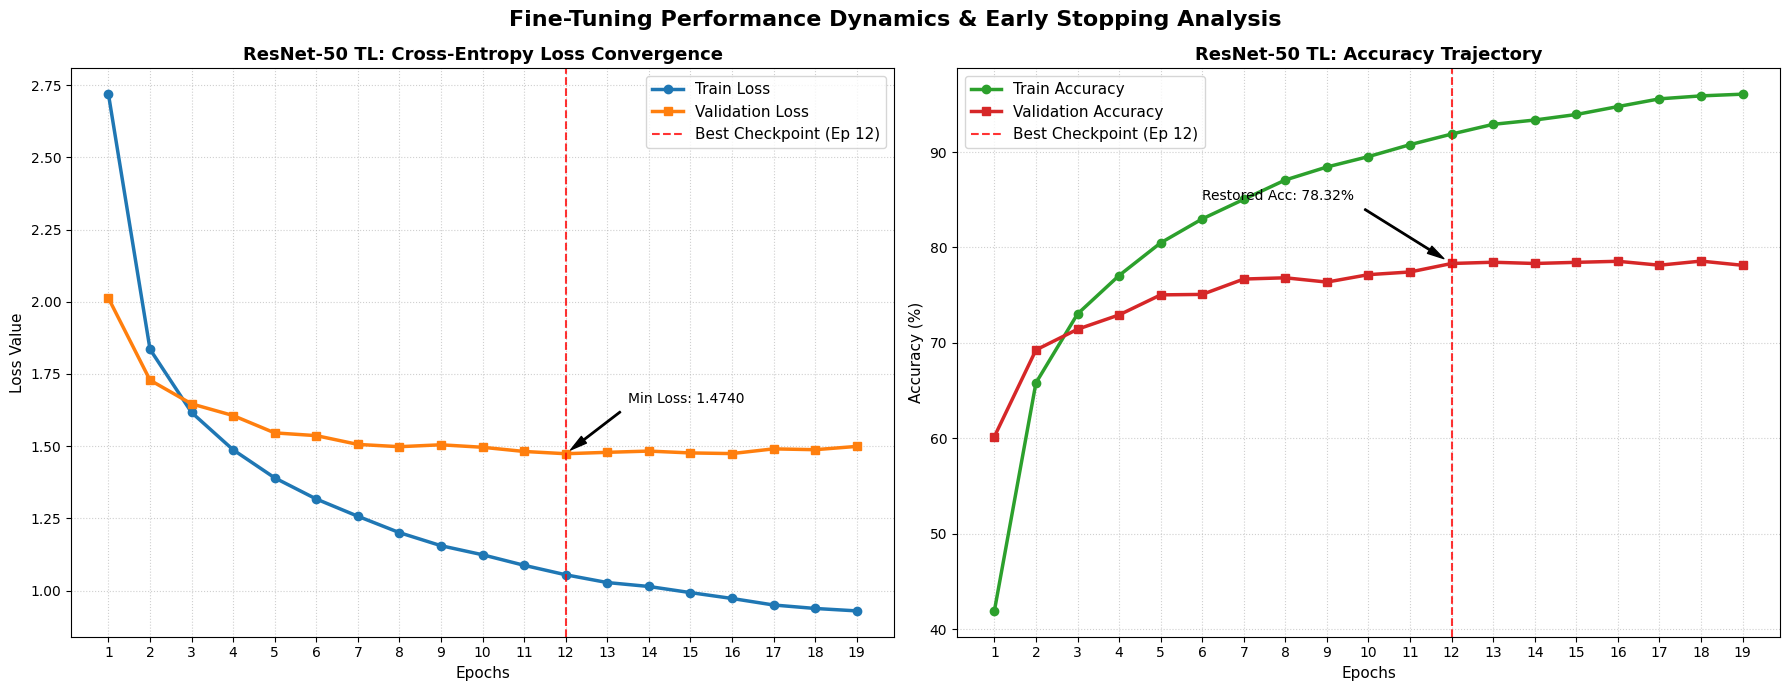

In [ ]:
# =====================================================================
# LEARNING CURVES: RESNET-50 TRANSFER LEARNING (LOSS & ACCURACY)
# =====================================================================
import matplotlib.pyplot as plt

# --- 1. POPULATE EXACT HISTORICAL RUN DATA FROM YOUR LOGS ---
epochs = list(range(1, 20))

# Exact loss history from your output
train_losses = [2.7187, 1.8356, 1.6168, 1.4875, 1.3904, 1.3172, 1.2575, 1.2008, 1.1556, 1.1242, 1.0877, 1.0549, 1.0280, 1.0144, 0.9932, 0.9729, 0.9503, 0.9383, 0.9299]
val_losses   = [2.0126, 1.7287, 1.6466, 1.6061, 1.5461, 1.5366, 1.5062, 1.4983, 1.5049, 1.4963, 1.4818, 1.4740, 1.4788, 1.4831, 1.4767, 1.4745, 1.4908, 1.4879, 1.4993]

# Exact accuracy history from your output
train_accs = [41.92, 65.81, 73.03, 77.06, 80.48, 82.99, 85.04, 87.07, 88.43, 89.52, 90.77, 91.88, 92.90, 93.35, 93.93, 94.76, 95.57, 95.88, 96.06]
val_accs   = [60.18, 69.26, 71.43, 72.93, 75.03, 75.08, 76.69, 76.82, 76.37, 77.15, 77.43, 78.32, 78.45, 78.32, 78.44, 78.55, 78.14, 78.57, 78.13]

# --- 2. CANVAS CREATION (Dual-Panel Layout) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Panel A: Loss Curves
ax1.plot(epochs, train_losses, label='Train Loss', color='#1f77b4', linewidth=2.5, marker='o')
ax1.plot(epochs, val_losses, label='Validation Loss', color='#ff7f0e', linewidth=2.5, marker='s')
ax1.axvline(x=12, color='red', linestyle='--', alpha=0.8, label='Best Checkpoint (Ep 12)')
ax1.set_title('ResNet-50 TL: Cross-Entropy Loss Convergence', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Loss Value', fontsize=11)
ax1.set_xticks(epochs)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(fontsize=11)

# Annotate the loss trough
ax1.annotate(f'Min Loss: 1.4740', xy=(12, 1.4740), xytext=(13.5, 1.65),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

# Panel B: Accuracy Curves
ax2.plot(epochs, train_accs, label='Train Accuracy', color='#2ca02c', linewidth=2.5, marker='o')
ax2.plot(epochs, val_accs, label='Validation Accuracy', color='#d62728', linewidth=2.5, marker='s')
ax2.axvline(x=12, color='red', linestyle='--', alpha=0.8, label='Best Checkpoint (Ep 12)')
ax2.set_title('ResNet-50 TL: Accuracy Trajectory', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=11)
ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_xticks(epochs)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(fontsize=11)

# Annotate the accuracy peak at the saved checkpoint
ax2.annotate(f'Restored Acc: 78.32%', xy=(12, 78.32), xytext=(6, 85),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

plt.suptitle('Fine-Tuning Performance Dynamics & Early Stopping Analysis', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

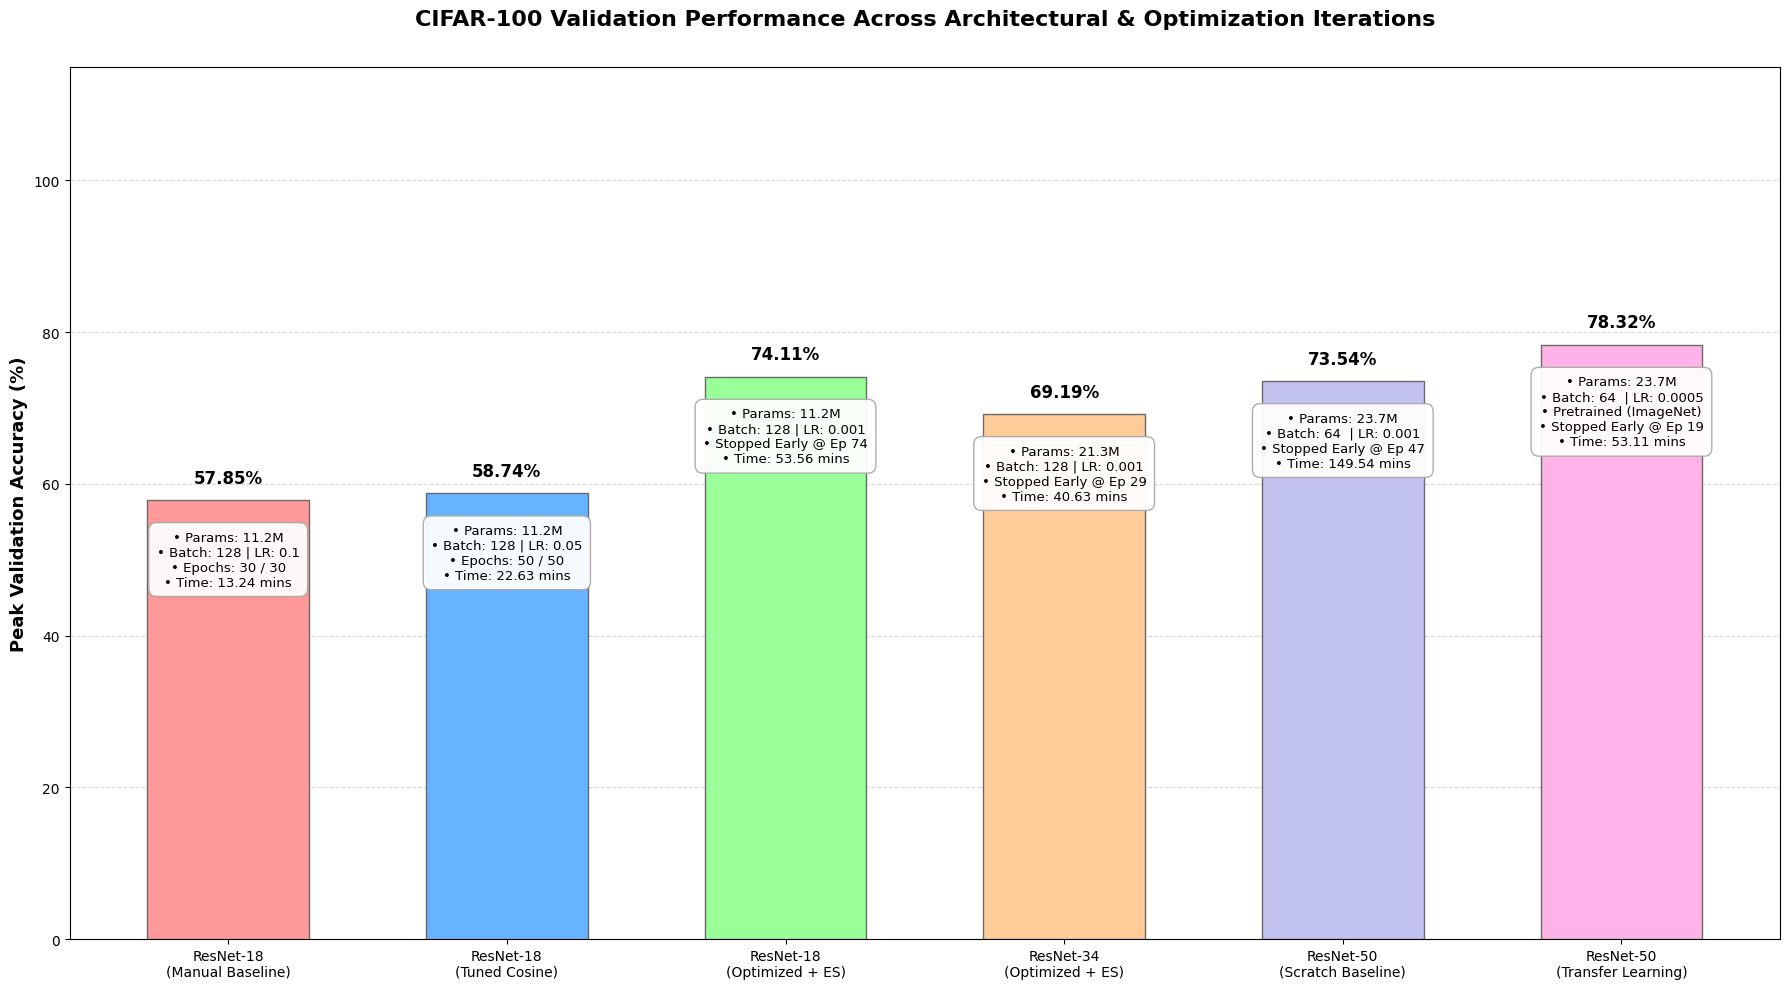

In [ ]:
# =====================================================================
# FINAL VERIFIED ARCHITECTURAL COMPARATIVE GRAPH: ALL 6 STEPS COMPLETE
# =====================================================================
import matplotlib.pyplot as plt

# --- 1. DATA PREPARATION FROM RAW VALIDATED LOGS ---
models = [
    'ResNet-18\n(Manual Baseline)',
    'ResNet-18\n(Tuned Cosine)',
    'ResNet-18\n(Optimized + ES)',
    'ResNet-34\n(Optimized + ES)',
    'ResNet-50\n(Scratch Baseline)',
    'ResNet-50\n(Transfer Learning)'
]

# The precise peak validation accuracies achieved sequentially across your steps
accuracies = [57.85, 58.74, 74.11, 69.19, 73.54, 78.32]

# Comprehensive architectural metadata aligned identically with your runs
parameter_labels = [
    "• Params: 11.2M\n• Batch: 128 | LR: 0.1\n• Epochs: 30 / 30\n• Time: 13.24 mins",
    "• Params: 11.2M\n• Batch: 128 | LR: 0.05\n• Epochs: 50 / 50\n• Time: 22.63 mins",
    "• Params: 11.2M\n• Batch: 128 | LR: 0.001\n• Stopped Early @ Ep 74\n• Time: 53.56 mins",
    "• Params: 21.3M\n• Batch: 128 | LR: 0.001\n• Stopped Early @ Ep 29\n• Time: 40.63 mins",
    "• Params: 23.7M\n• Batch: 64  | LR: 0.001\n• Stopped Early @ Ep 47\n• Time: 149.54 mins",
    "• Params: 23.7M\n• Batch: 64  | LR: 0.0005\n• Pretrained (ImageNet)\n• Stopped Early @ Ep 19\n• Time: 53.11 mins"
]

# --- 2. CONFIGURATION & CANVAS LAYOUT ---
plt.figure(figsize=(18, 10))
# Distinct color map highlighting the progression phases
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

# Render comparison bars
bars = plt.bar(models, accuracies, color=colors, edgecolor='dimgray', width=0.58, zorder=3)

# --- 3. STYLING & TEXT DATA PLACEMENT ---
plt.title('CIFAR-100 Validation Performance Across Architectural & Optimization Iterations',
          fontsize=16, fontweight='bold', pad=30)
plt.ylabel('Peak Validation Accuracy (%)', fontsize=13, fontweight='bold')
plt.ylim(0, 115)  # Generous headroom for labels
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)

# Apply dynamic textual badges to each bar
for bar, acc, text in zip(bars, accuracies, parameter_labels):
    yval = bar.get_height()

    # 1. Plot exact final floating-point value on top of the bar
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.8, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

    # 2. Plot the structured configuration parameter box cleanly inside/below the bar crest
    plt.text(bar.get_x() + bar.get_width()/2.0, yval - 4.0, text,
             ha='center', va='top', fontsize=9.5, color='black', fontweight='medium',
             bbox=dict(boxstyle="round,pad=0.6", facecolor='white', edgecolor='darkgray', alpha=0.94))

plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# STEP 6: RESNET-50 WITH TRANSFER LEARNING & INPUT UPSCALING (224x224)
# =====================================================================
import time
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. RUNTIME RECOVERY & DATA BOOTSTRAP ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Target Execution Device: {device}")

# Pretrained models expect 224x224 input images and ImageNet normalization stats
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),              # Hitting the 80-90% accuracy sweet spot
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),              # Match test data resolution to train data
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

data_dir = "./data"
train_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=True, download=False, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR100(root=data_dir, train=False, download=False, transform=transform_test)

# --- 2. CONFIGURATION & LOADERS ---
BATCH_SIZE = 64             # Lower batch size protects GPU memory during 224x224 upscaling
EPOCHS = 30                 # Upscaled transfer learning models converge very early
LEARNING_RATE = 0.0005      # Small learning rate preserves fine-grained pretrained shapes
WEIGHT_DECAY = 1e-4
PATIENCE = 5                # Shorter patience limits resource consumption on long runs

best_val_loss = float('inf')
patience_counter = 0

print(f"--- 🚀 Starting Step 6: ResNet-50 (Pretrained Transfer Learning) ---")

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# --- 3. ARCHITECTURE BUILD (Standard Pretrained ResNet-50) ---
model_pt_r50 = torchvision.models.resnet50(weights=ResNet50_Weights.DEFAULT)

# NOTE: We keep standard conv1 and maxpool configurations active because
# the images are now upscaled to native 224x224 resolution.

# Modify final linear layer for CIFAR-100 target outputs
num_ftrs = model_pt_r50.fc.in_features
model_pt_r50.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_ftrs, 100)
)
model_pt_r50 = model_pt_r50.to(device)

# --- 4. OPTIMIZATION SETTING ---
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_pt_r50.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

ptr50_losses, ptr50_val_losses = [], []
ptr50_accs, ptr50_val_accs = [], []

# --- 5. EXECUTION TRAINING LOOP ---
start_time = time.time()
for epoch in range(EPOCHS):
    model_pt_r50.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_pt_r50(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = correct / total

    # Validation Phase
    model_pt_r50.eval()
    running_val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_pt_r50(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    epoch_val_loss = running_val_loss / len(test_dataset)
    epoch_val_acc = val_correct / val_total
    scheduler.step()

    ptr50_losses.append(epoch_train_loss)
    ptr50_val_losses.append(epoch_val_loss)
    ptr50_accs.append(epoch_train_acc)
    ptr50_val_accs.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc*100:.2f}% | Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc*100:.2f}%")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model_pt_r50.state_dict(), 'best_pretrained_224_r50.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"🛑 Early stopping triggered at epoch {epoch+1}! Baseline optimization achieved.")
            break

# Load optimal parameters back to active device
model_pt_r50.load_state_dict(torch.load('best_pretrained_224_r50.pth'))
print(f"Done! Step 6 training complete in: {(time.time() - start_time)/60:.2f} mins.\n")

# --- 6. FINAL PERFORMANCE EVALUATION METRICS ---
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_pt_r50(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("============================================================")
print("     FINAL CLASSIFICATION REPORT: RESNET-50 (PRETRAINED 224)")
print("============================================================")
print(classification_report(all_labels, all_preds))

Target Execution Device: cpu


RuntimeError: Dataset not found or corrupted. You can use download=True to download it